# BigEarthNet-S2 B08 5x5 Mosaic Dataset Creation

Create split-compliant 600x600 NIR mosaics by stitching 5x5 neighborhoods of BigEarthNet-S2 `B08` patches.

Protocol:
- `B08` only, stored as single-band uint16 GeoTIFFs.
- 5x5 source patches, each 120x120 pixels, producing 600x600 mosaics.
- Natural stride-3 anchor rule: `H % 3 == 0` and `V % 3 == 0`.
- Official split compliance: all 25 patches must exist in `metadata.parquet` and all 25 must share the same split.
- Mosaic labels are the sorted set union of the 25 source patch label lists.

Run cells top to bottom. The writer is idempotent by default and skips existing GeoTIFFs unless `OVERWRITE=True`.

## 1. Setup

Configure paths, constants, output directories, and dependencies. The notebook is intended to run with the `diffusers-dev` kernel from the repository root.

In [3]:
from __future__ import annotations

import json
import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import Affine
from tqdm.auto import tqdm


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(f"Could not infer repository root from {start}")


REPO_ROOT = find_repo_root()
RAW_ROOT = REPO_ROOT / "data/raw/BigEarthNet-S2"
METADATA_PATH = RAW_ROOT / "metadata.parquet"
OUTPUT_ROOT = REPO_ROOT / "data/derived/bigearthnet_s2_b08_5x5_stride3"
IMAGE_ROOT = OUTPUT_ROOT / "images"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
PREVIEW_ROOT = OUTPUT_ROOT / "previews"
STATS_ROOT = OUTPUT_ROOT / "stats"

BAND = "B08"
WINDOW_SIZE = 5
PATCH_SIZE = 120
MOSAIC_SIZE = WINDOW_SIZE * PATCH_SIZE
STRIDE = 3
OFFSET = (0, 0)
EXPECTED_COUNTS = {"train": 13618, "validation": 6308, "test": 8773}
SPLIT_ORDER = ["train", "validation", "test"]

# Writer controls. For a quick smoke test, set LIMIT_PER_SPLIT to a small integer.
WRITE_MOSAICS = True
OVERWRITE = False
LIMIT_PER_SPLIT: int | None = None

for path in [IMAGE_ROOT, MANIFEST_ROOT, PREVIEW_ROOT, STATS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Raw root:        {RAW_ROOT}")
print(f"Metadata:        {METADATA_PATH}")
print(f"Output root:     {OUTPUT_ROOT}")
print(f"Protocol: {BAND}, {WINDOW_SIZE}x{WINDOW_SIZE}, stride={STRIDE}, offset={OFFSET}")

Repository root: /projets/Fbassignana/diffusers_try/flow_matching_trial
Raw root:        /projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/BigEarthNet-S2
Metadata:        /projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/BigEarthNet-S2/metadata.parquet
Output root:     /projets/Fbassignana/diffusers_try/flow_matching_trial/data/derived/bigearthnet_s2_b08_5x5_stride3
Protocol: B08, 5x5, stride=3, offset=(0, 0)


/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Metadata

Load the official BigEarthNet v2 metadata. These rows are the recommended patches and include the official split and patch-level multi-label annotations.

In [2]:
metadata = pd.read_parquet(METADATA_PATH, columns=["patch_id", "labels", "split"])

required_columns = {"patch_id", "labels", "split"}
missing_columns = required_columns.difference(metadata.columns)
assert not missing_columns, f"Missing metadata columns: {sorted(missing_columns)}"
assert metadata["patch_id"].notna().all(), "metadata.parquet contains null patch_id values"
assert metadata["split"].notna().all(), "metadata.parquet contains null split values"
assert not metadata["patch_id"].duplicated().any(), "metadata.parquet contains duplicate patch_id values"


def normalize_labels(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple, set)):
        return sorted({str(item) for item in value})
    return [str(value)]


metadata["labels"] = metadata["labels"].map(normalize_labels)
split_by_patch_id = dict(zip(metadata["patch_id"], metadata["split"], strict=True))
labels_by_patch_id = dict(zip(metadata["patch_id"], metadata["labels"], strict=True))

print(f"Metadata rows: {len(metadata):,}")
print(metadata["split"].value_counts().reindex(SPLIT_ORDER).to_string())
print("\nExample rows:")
display(metadata.head(3))

Metadata rows: 480,038
split
train         237871
validation    122342
test          119825

Example rows:


,patch_id,labels,split
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Mixed fores...",test
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Inland wate...",test
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Coniferous ...",test


## 3. Index Patch Grid

Scan BigEarthNet-S2 scene directories and index each patch by `(H-Order, V-Order)`. Only patches with an existing `B08` GeoTIFF are retained.

In [3]:
PATCH_SUFFIX_RE = re.compile(r"_(?P<h>\d+)_(?P<v>\d+)$")


def parse_patch_position(scene_name: str, patch_name: str) -> tuple[int, int] | None:
    prefix = f"{scene_name}_"
    if not patch_name.startswith(prefix):
        return None
    match = PATCH_SUFFIX_RE.search(patch_name)
    if match is None:
        return None
    return int(match.group("h")), int(match.group("v"))


grid_by_scene: dict[str, dict[tuple[int, int], dict[str, str]]] = {}
missing_b08_paths: list[str] = []

scene_dirs = sorted(path for path in RAW_ROOT.iterdir() if path.is_dir())
for scene_dir in tqdm(scene_dirs, desc="Indexing scenes"):
    scene_grid: dict[tuple[int, int], dict[str, str]] = {}
    for patch_dir in scene_dir.iterdir():
        if not patch_dir.is_dir():
            continue
        position = parse_patch_position(scene_dir.name, patch_dir.name)
        if position is None:
            continue
        b08_path = patch_dir / f"{patch_dir.name}_{BAND}.tif"
        if not b08_path.exists():
            missing_b08_paths.append(str(b08_path.relative_to(REPO_ROOT)))
            continue
        scene_grid[position] = {
            "patch_id": patch_dir.name,
            "b08_path": str(b08_path.relative_to(REPO_ROOT)),
        }
    if scene_grid:
        grid_by_scene[scene_dir.name] = scene_grid

num_patches = sum(len(grid) for grid in grid_by_scene.values())
print(f"Indexed scenes: {len(grid_by_scene):,}")
print(f"Indexed patches with {BAND}: {num_patches:,}")
print(f"Missing {BAND} files: {len(missing_b08_paths):,}")
assert not missing_b08_paths, f"Found missing {BAND} files, first examples: {missing_b08_paths[:5]}"

Indexing scenes: 100%|██████████| 115/115 [00:11<00:00,  9.74it/s]

Indexed scenes: 115
Indexed patches with B08: 549,488
Missing B08 files: 0


## 4. Build Candidate Windows

Create stride-3, split-compliant 5x5 windows for all official splits. A window is retained only if all 25 patches are present, metadata-listed, and share one split.

In [4]:
def window_cells(
    scene_grid: dict[tuple[int, int], dict[str, str]],
    anchor_h: int,
    anchor_v: int,
) -> list[dict[str, str]] | None:
    cells: list[dict[str, str]] = []
    for dy in range(WINDOW_SIZE):
        for dx in range(WINDOW_SIZE):
            cell = scene_grid.get((anchor_h + dx, anchor_v + dy))
            if cell is None:
                return None
            cells.append(cell)
    return cells


def make_sample_id(scene: str, anchor_h: int, anchor_v: int) -> str:
    return f"{scene}_H{anchor_h:03d}_V{anchor_v:03d}_{BAND}_{WINDOW_SIZE}x{WINDOW_SIZE}_stride{STRIDE}"


candidates: list[dict[str, Any]] = []
skip_counts = Counter()

for scene, scene_grid in tqdm(sorted(grid_by_scene.items()), desc="Building windows"):
    hs = [h for h, _ in scene_grid]
    vs = [v for _, v in scene_grid]
    if not hs or not vs:
        continue
    min_h, max_h = min(hs), max(hs)
    min_v, max_v = min(vs), max(vs)

    for anchor_v in range(min_v, max_v - WINDOW_SIZE + 2):
        if anchor_v % STRIDE != OFFSET[1]:
            continue
        for anchor_h in range(min_h, max_h - WINDOW_SIZE + 2):
            if anchor_h % STRIDE != OFFSET[0]:
                continue
            cells = window_cells(scene_grid, anchor_h, anchor_v)
            if cells is None:
                skip_counts["incomplete_geometry"] += 1
                continue

            patch_ids = [cell["patch_id"] for cell in cells]
            source_splits = [split_by_patch_id.get(patch_id) for patch_id in patch_ids]
            if any(split is None for split in source_splits):
                skip_counts["missing_metadata"] += 1
                continue
            unique_splits = sorted(set(source_splits))
            if len(unique_splits) != 1:
                skip_counts["mixed_split"] += 1
                continue

            labels = sorted(
                {
                    label
                    for patch_id in patch_ids
                    for label in labels_by_patch_id.get(patch_id, [])
                }
            )
            split = unique_splits[0]
            sample_id = make_sample_id(scene, anchor_h, anchor_v)
            image_rel_path = Path("data/derived/bigearthnet_s2_b08_5x5_stride3/images") / split / f"{sample_id}.tif"

            candidates.append(
                {
                    "sample_id": sample_id,
                    "scene": scene,
                    "anchor_h": anchor_h,
                    "anchor_v": anchor_v,
                    "split": split,
                    "labels": labels,
                    "source_patch_ids": patch_ids,
                    "source_b08_paths": [cell["b08_path"] for cell in cells],
                    "height": MOSAIC_SIZE,
                    "width": MOSAIC_SIZE,
                    "band": BAND,
                    "window_size": WINDOW_SIZE,
                    "stride": STRIDE,
                    "offset": list(OFFSET),
                    "image_path": str(image_rel_path),
                }
            )

split_rank = {split: index for index, split in enumerate(SPLIT_ORDER)}
candidates.sort(
    key=lambda row: (
        split_rank.get(row["split"], len(SPLIT_ORDER)),
        row["scene"],
        row["anchor_v"],
        row["anchor_h"],
    )
)

candidate_counts = Counter(row["split"] for row in candidates)
print("Candidate counts:")
print(pd.Series(candidate_counts).reindex(SPLIT_ORDER).to_string())
print("\nSkip counts:")
print(pd.Series(skip_counts).sort_index().to_string())

Building windows: 100%|██████████| 115/115 [00:02<00:00, 52.81it/s]

Candidate counts:
train         13618
validation     6308
test           8773

Skip counts:
incomplete_geometry    18998
missing_metadata       10791
mixed_split             8353


## 5. Pre-Creation Sanity Checks

Confirm the candidate set matches the selected protocol before materializing data.

In [5]:
actual_counts = {split: candidate_counts.get(split, 0) for split in SPLIT_ORDER}
assert actual_counts == EXPECTED_COUNTS, f"Unexpected candidate counts: {actual_counts} != {EXPECTED_COUNTS}"
assert all(len(row["source_patch_ids"]) == WINDOW_SIZE * WINDOW_SIZE for row in candidates)
assert all(len(row["source_b08_paths"]) == WINDOW_SIZE * WINDOW_SIZE for row in candidates)
assert all(row["height"] == MOSAIC_SIZE and row["width"] == MOSAIC_SIZE for row in candidates)
assert all(row["labels"] == sorted(set(row["labels"])) for row in candidates)

# Reconfirm split consistency from metadata lookups.
for row in candidates[:1000] + candidates[-1000:]:
    splits = {split_by_patch_id[patch_id] for patch_id in row["source_patch_ids"]}
    assert splits == {row["split"]}, (row["sample_id"], splits)

summary = pd.DataFrame(
    [
        {
            "split": split,
            "samples": actual_counts[split],
            "expected": EXPECTED_COUNTS[split],
        }
        for split in SPLIT_ORDER
    ]
)
display(summary)
print(f"Total candidates: {len(candidates):,}")

,split,samples,expected
0,train,13618,13618
1,validation,6308,6308
2,test,8773,8773


Total candidates: 28,699


,label,mosaic_count
0,"Transitional woodland, shrub",20177
1,Arable land,19628
2,"Land principally occupied by agriculture, with...",18780
3,Broad-leaved forest,17926
4,Mixed forest,17246
5,Coniferous forest,15445
6,Complex cultivation patterns,14522
7,Urban fabric,13377
8,Pastures,12399
9,Inland waters,10395


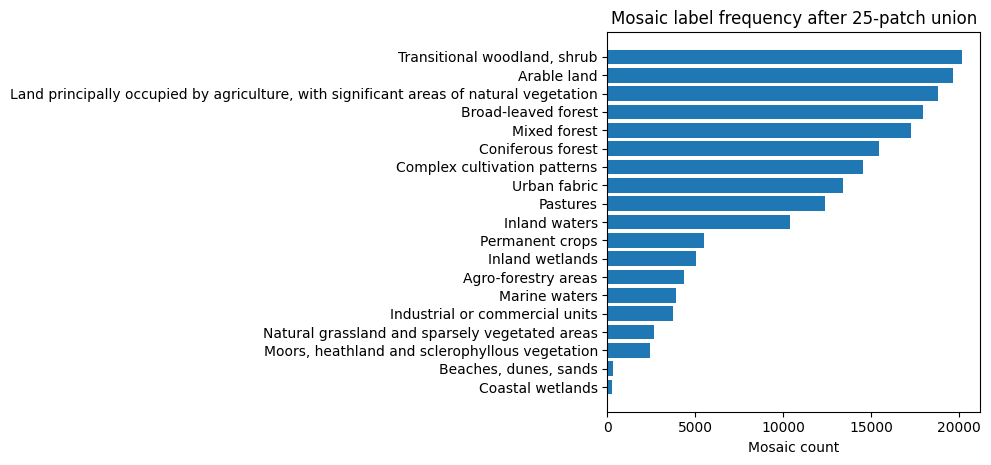

In [6]:
label_counts = Counter(label for row in candidates for label in row["labels"])
label_frame = pd.DataFrame(
    sorted(label_counts.items(), key=lambda item: (-item[1], item[0])),
    columns=["label", "mosaic_count"],
)

display(label_frame)

fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * len(label_frame))))
ax.barh(label_frame["label"], label_frame["mosaic_count"])
ax.invert_yaxis()
ax.set_title("Mosaic label frequency after 25-patch union")
ax.set_xlabel("Mosaic count")
plt.tight_layout()
plt.show()

## 6. Mosaic Writer

Write compressed, georeferenced, single-band uint16 GeoTIFF mosaics. This cell is idempotent by default: existing files are skipped unless `OVERWRITE=True`.

In [7]:
def assert_close_transform(actual: Affine, expected: Affine, path: Path) -> None:
    if not np.allclose(tuple(actual), tuple(expected), atol=1e-6):
        raise AssertionError(f"Unexpected transform for {path}: {actual} != {expected}")


def read_mosaic(row: dict[str, Any]) -> tuple[np.ndarray, dict[str, Any]]:
    source_paths = [REPO_ROOT / rel_path for rel_path in row["source_b08_paths"]]
    arrays_by_row: list[list[np.ndarray]] = []

    with rasterio.open(source_paths[0]) as first_src:
        first_profile = first_src.profile.copy()
        first_transform = first_src.transform
        first_crs = first_src.crs
        first_dtype = first_src.dtypes[0]
        first_shape = (first_src.height, first_src.width)
        first_count = first_src.count

    assert first_shape == (PATCH_SIZE, PATCH_SIZE), f"Unexpected patch shape {first_shape}"
    assert first_dtype == "uint16", f"Unexpected dtype {first_dtype}"
    assert first_count == 1, f"Expected single-band source, got {first_count}"

    index = 0
    for dy in range(WINDOW_SIZE):
        row_arrays: list[np.ndarray] = []
        for dx in range(WINDOW_SIZE):
            path = source_paths[index]
            with rasterio.open(path) as src:
                assert src.count == first_count, f"Band count mismatch for {path}"
                assert src.dtypes[0] == first_dtype, f"Dtype mismatch for {path}"
                assert (src.height, src.width) == first_shape, f"Shape mismatch for {path}"
                assert src.crs == first_crs, f"CRS mismatch for {path}"
                assert_close_transform(
                    src.transform,
                    first_transform * Affine.translation(dx * PATCH_SIZE, dy * PATCH_SIZE),
                    path,
                )
                row_arrays.append(src.read(1))
            index += 1
        arrays_by_row.append(row_arrays)

    mosaic = np.concatenate([np.concatenate(row_arrays, axis=1) for row_arrays in arrays_by_row], axis=0)
    assert mosaic.shape == (MOSAIC_SIZE, MOSAIC_SIZE), f"Unexpected mosaic shape {mosaic.shape}"
    assert mosaic.dtype == np.uint16, f"Unexpected mosaic dtype {mosaic.dtype}"

    output_profile = first_profile.copy()
    output_profile.update(
        driver="GTiff",
        height=MOSAIC_SIZE,
        width=MOSAIC_SIZE,
        count=1,
        dtype="uint16",
        transform=first_transform,
        compress="deflate",
        predictor=2,
        BIGTIFF="IF_SAFER",
    )
    return mosaic, output_profile


def selected_rows_for_writing(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    if LIMIT_PER_SPLIT is None:
        return rows
    selected: list[dict[str, Any]] = []
    per_split = Counter()
    for row in rows:
        if per_split[row["split"]] >= LIMIT_PER_SPLIT:
            continue
        selected.append(row)
        per_split[row["split"]] += 1
    return selected


rows_to_write = selected_rows_for_writing(candidates)
print(f"Rows selected for writing: {len(rows_to_write):,} / {len(candidates):,}")
print(f"WRITE_MOSAICS={WRITE_MOSAICS}, OVERWRITE={OVERWRITE}, LIMIT_PER_SPLIT={LIMIT_PER_SPLIT}")

write_counts = Counter()
skip_existing_counts = Counter()

if WRITE_MOSAICS:
    for row in tqdm(rows_to_write, desc="Writing mosaics"):
        output_path = REPO_ROOT / row["image_path"]
        output_path.parent.mkdir(parents=True, exist_ok=True)
        if output_path.exists() and not OVERWRITE:
            skip_existing_counts[row["split"]] += 1
            continue
        mosaic, profile = read_mosaic(row)
        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(mosaic, 1)
        write_counts[row["split"]] += 1

print("Written:")
print(pd.Series(write_counts).reindex(SPLIT_ORDER, fill_value=0).to_string())
print("\nSkipped existing:")
print(pd.Series(skip_existing_counts).reindex(SPLIT_ORDER, fill_value=0).to_string())

Rows selected for writing: 28,699 / 28,699
WRITE_MOSAICS=True, OVERWRITE=False, LIMIT_PER_SPLIT=None


Writing mosaics: 100%|██████████| 28699/28699 [27:03<00:00, 17.67it/s] 

Written:
train         13618
validation     6308
test           8773

Skipped existing:
train         0
validation    0
test          0


## 7. Manifest Writer

Write JSONL manifests for each split and one combined manifest. Manifests include the unioned labels, source patch IDs, source B08 paths, and intended output image path.

In [8]:
def write_jsonl(path: Path, rows: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        for row in rows:
            file.write(json.dumps(row, sort_keys=True) + "\n")


rows_by_split = {split: [row for row in candidates if row["split"] == split] for split in SPLIT_ORDER}
for split, rows in rows_by_split.items():
    write_jsonl(MANIFEST_ROOT / f"{split}.jsonl", rows)
write_jsonl(MANIFEST_ROOT / "all.jsonl", candidates)

protocol = {
    "source_root": str(RAW_ROOT.relative_to(REPO_ROOT)),
    "metadata_path": str(METADATA_PATH.relative_to(REPO_ROOT)),
    "output_root": str(OUTPUT_ROOT.relative_to(REPO_ROOT)),
    "band": BAND,
    "window_size": WINDOW_SIZE,
    "patch_size": PATCH_SIZE,
    "mosaic_size": MOSAIC_SIZE,
    "stride": STRIDE,
    "offset": list(OFFSET),
    "expected_counts": EXPECTED_COUNTS,
    "actual_counts": actual_counts,
    "label_policy": "sorted set union across the 25 source patch label lists",
}
with (MANIFEST_ROOT / "dataset_protocol.json").open("w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2, sort_keys=True)
    file.write("\n")

print("Wrote manifests:")
for path in sorted(MANIFEST_ROOT.glob("*.jsonl")):
    print(f"  {path.relative_to(REPO_ROOT)}")
print(f"  {(MANIFEST_ROOT / 'dataset_protocol.json').relative_to(REPO_ROOT)}")

Wrote manifests:
  data/derived/bigearthnet_s2_b08_5x5_stride3/manifests/all.jsonl
  data/derived/bigearthnet_s2_b08_5x5_stride3/manifests/test.jsonl
  data/derived/bigearthnet_s2_b08_5x5_stride3/manifests/train.jsonl
  data/derived/bigearthnet_s2_b08_5x5_stride3/manifests/validation.jsonl
  data/derived/bigearthnet_s2_b08_5x5_stride3/manifests/dataset_protocol.json


## 8. Preview And Output Sanity Checks

Sample output mosaics from each split, verify basic GeoTIFF properties, and save contrast-stretched PNG previews. The red grid marks the original 120-pixel patch boundaries.

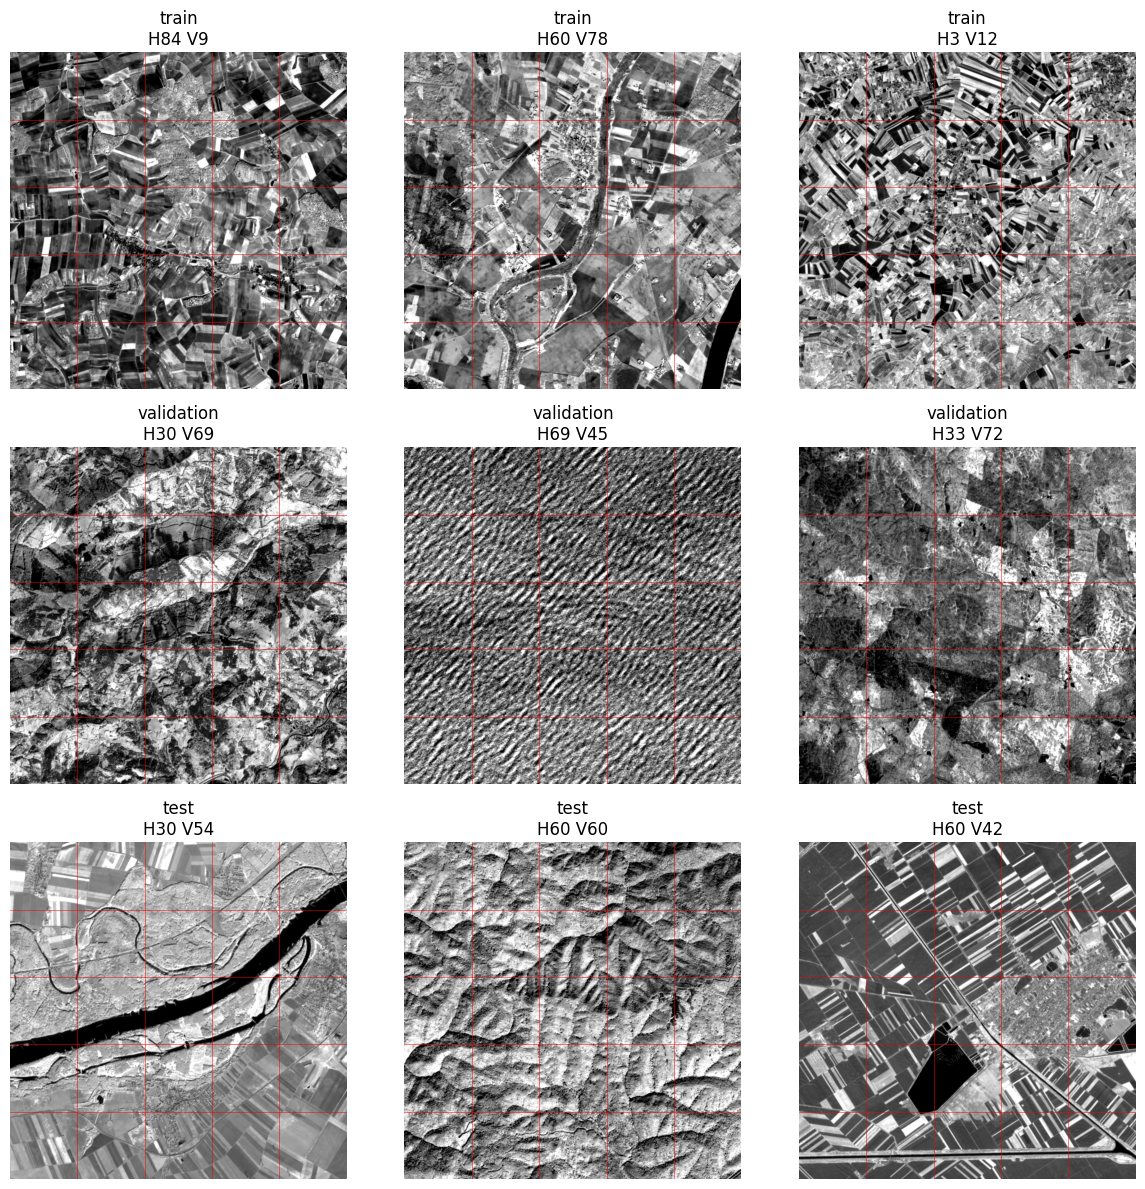

,sample_id,split,min,max,p2,p50,p98,crs,transform
0,S2A_MSIL2A_20180506T100031_N9999_R122_T33UWP_H...,train,351,6756,2034.0,3212.0,5004.0,EPSG:32633,"(10.0, 0.0, 600780.0, 0.0, -10.0, 5389200.0, 0..."
1,S2A_MSIL2A_20180510T094031_N9999_R036_T35VLC_H...,train,157,6792,1410.0,2918.0,4444.0,EPSG:32635,"(10.0, 0.0, 372000.0, 0.0, -10.0, 6206400.0, 0..."
2,S2B_MSIL2A_20180502T093039_N9999_R136_T34TEP_H...,train,1160,7980,2144.0,3694.0,4980.0,EPSG:32634,"(10.0, 0.0, 503580.0, 0.0, -10.0, 4885620.0, 0..."
3,S2A_MSIL2A_20180506T100031_N9999_R122_T33UWP_H...,validation,387,7352,1434.0,3308.0,5656.0,EPSG:32633,"(10.0, 0.0, 535980.0, 0.0, -10.0, 5317200.0, 0..."
4,S2A_MSIL2A_20180529T115401_N9999_R023_T29UNB_H...,validation,41,294,91.0,133.0,189.0,EPSG:32629,"(10.0, 0.0, 582780.0, 0.0, -10.0, 6146040.0, 0..."
5,S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_H...,validation,140,6456,2424.0,3364.0,4764.0,EPSG:32629,"(10.0, 0.0, 539580.0, 0.0, -10.0, 4213620.0, 0..."
6,S2B_MSIL2A_20170831T095029_N9999_R079_T33UXP_H...,test,263,9240,342.0,2620.0,4100.0,EPSG:32633,"(10.0, 0.0, 636000.0, 0.0, -10.0, 5335200.0, 0..."
7,S2B_MSIL2A_20170914T093029_N9999_R136_T34TEQ_H...,test,498,5324,1576.0,3054.0,4236.0,EPSG:32634,"(10.0, 0.0, 571980.0, 0.0, -10.0, 4928040.0, 0..."
8,S2A_MSIL2A_20180430T094031_N9999_R036_T34TCR_H...,test,300,5892,469.0,1890.0,4728.0,EPSG:32634,"(10.0, 0.0, 372000.0, 0.0, -10.0, 5049600.0, 0..."


Preview PNGs saved under data/derived/bigearthnet_s2_b08_5x5_stride3/previews


In [9]:
PREVIEW_SAMPLES_PER_SPLIT = 3
PREVIEW_SEED = 13


def contrast_stretch(array: np.ndarray, lower: float = 2, upper: float = 98) -> np.ndarray:
    lo, hi = np.percentile(array, [lower, upper])
    if hi <= lo:
        return np.zeros(array.shape, dtype=np.uint8)
    scaled = np.clip((array.astype(np.float32) - lo) / (hi - lo), 0, 1)
    return (scaled * 255).astype(np.uint8)


def sample_rows(rows: list[dict[str, Any]], n: int, seed: int) -> list[dict[str, Any]]:
    rng = random.Random(seed)
    if len(rows) <= n:
        return list(rows)
    return rng.sample(rows, n)


preview_rows: list[dict[str, Any]] = []
for split in SPLIT_ORDER:
    preview_rows.extend(sample_rows(rows_by_split[split], PREVIEW_SAMPLES_PER_SPLIT, PREVIEW_SEED))

fig, axes = plt.subplots(len(SPLIT_ORDER), PREVIEW_SAMPLES_PER_SPLIT, figsize=(4 * PREVIEW_SAMPLES_PER_SPLIT, 4 * len(SPLIT_ORDER)))
if len(SPLIT_ORDER) == 1:
    axes = np.asarray([axes])

preview_stats = []
for row_index, split in enumerate(SPLIT_ORDER):
    rows = [row for row in preview_rows if row["split"] == split]
    for col_index, row in enumerate(rows):
        output_path = REPO_ROOT / row["image_path"]
        assert output_path.exists(), f"Missing output file: {output_path}"
        with rasterio.open(output_path) as src:
            array = src.read(1)
            assert src.width == MOSAIC_SIZE and src.height == MOSAIC_SIZE
            assert src.count == 1
            assert src.dtypes[0] == "uint16"
            preview_stats.append(
                {
                    "sample_id": row["sample_id"],
                    "split": split,
                    "min": int(array.min()),
                    "max": int(array.max()),
                    "p2": float(np.percentile(array, 2)),
                    "p50": float(np.percentile(array, 50)),
                    "p98": float(np.percentile(array, 98)),
                    "crs": str(src.crs),
                    "transform": tuple(src.transform),
                }
            )
        preview = contrast_stretch(array)
        preview_path = PREVIEW_ROOT / split / f"{row['sample_id']}_preview.png"
        preview_path.parent.mkdir(parents=True, exist_ok=True)
        plt.imsave(preview_path, preview, cmap="gray")

        ax = axes[row_index, col_index]
        ax.imshow(preview, cmap="gray")
        for boundary in range(PATCH_SIZE, MOSAIC_SIZE, PATCH_SIZE):
            ax.axhline(boundary - 0.5, color="red", linewidth=0.5, alpha=0.7)
            ax.axvline(boundary - 0.5, color="red", linewidth=0.5, alpha=0.7)
        ax.set_title(f"{split}\nH{row['anchor_h']} V{row['anchor_v']}")
        ax.axis("off")

plt.tight_layout()
plt.show()

display(pd.DataFrame(preview_stats))
print(f"Preview PNGs saved under {PREVIEW_ROOT.relative_to(REPO_ROOT)}")

In [10]:
# Manifest integrity checks against output files.
for split, rows in rows_by_split.items():
    manifest_path = MANIFEST_ROOT / f"{split}.jsonl"
    assert manifest_path.exists(), f"Missing manifest {manifest_path}"
    loaded_rows = [json.loads(line) for line in manifest_path.read_text().splitlines()]
    assert len(loaded_rows) == EXPECTED_COUNTS[split]
    assert all(len(row["source_patch_ids"]) == WINDOW_SIZE * WINDOW_SIZE for row in loaded_rows)
    assert all(row["labels"] == sorted(set(row["labels"])) for row in loaded_rows)

existing_counts = Counter()
for row in candidates:
    if (REPO_ROOT / row["image_path"]).exists():
        existing_counts[row["split"]] += 1

print("Existing GeoTIFF counts:")
print(pd.Series(existing_counts).reindex(SPLIT_ORDER, fill_value=0).to_string())
if LIMIT_PER_SPLIT is None and WRITE_MOSAICS:
    assert {split: existing_counts[split] for split in SPLIT_ORDER} == EXPECTED_COUNTS

Existing GeoTIFF counts:
train         13618
validation     6308
test           8773


## 9. Dataset Statistics

Compute exact train-split B08 statistics using a streaming uint16 histogram. Percentiles are derived from the histogram, so this avoids loading all train pixels into memory.

In [2]:
def percentile_from_histogram(hist: np.ndarray, percentile: float) -> int:
    assert 0 <= percentile <= 100
    if hist.sum() == 0:
        raise ValueError("Cannot compute percentile from an empty histogram")
    threshold = (percentile / 100.0) * (hist.sum() - 1)
    cumulative = np.cumsum(hist)
    return int(np.searchsorted(cumulative, threshold, side="right"))


train_hist = np.zeros(65536, dtype=np.int64)
train_rows = rows_by_split["train"]
missing_train_outputs = []

for row in tqdm(train_rows, desc="Computing train B08 stats"):
    image_path = REPO_ROOT / row["image_path"]
    if not image_path.exists():
        missing_train_outputs.append(str(image_path.relative_to(REPO_ROOT)))
        continue
    with rasterio.open(image_path) as src:
        array = src.read(1)
    train_hist += np.bincount(array.ravel(), minlength=65536)

assert not missing_train_outputs, f"Missing train outputs, first examples: {missing_train_outputs[:5]}"
values = np.arange(65536, dtype=np.float64)
weights = train_hist.astype(np.float64)
pixel_count = int(train_hist.sum())
mean = float((values * weights).sum() / pixel_count)
variance = float((((values - mean) ** 2) * weights).sum() / pixel_count)
nonzero_bins = np.flatnonzero(train_hist)

train_stats = {
    "split": "train",
    "sample_count": len(train_rows),
    "pixel_count": pixel_count,
    "min": int(nonzero_bins[0]),
    "max": int(nonzero_bins[-1]),
    "mean": mean,
    "std": math.sqrt(variance),
    "percentiles": {
        str(percentile): percentile_from_histogram(train_hist, percentile)
        for percentile in [1, 2, 5, 50, 95, 98, 99]
    },
}

stats_path = STATS_ROOT / "train_b08_stats.json"
with stats_path.open("w", encoding="utf-8") as file:
    json.dump(train_stats, file, indent=2, sort_keys=True)
    file.write("\n")

print(f"Wrote {stats_path.relative_to(REPO_ROOT)}")
print(json.dumps(train_stats, indent=2))

NameError: name 'np' is not defined

### 9.1 Pixel Value Distribution And Normalization Diagnostics

Inspect the raw B08 digital-number distribution, compare splits, and derive train-only normalization constants that can be reused in training configs or dataset transforms.

In [4]:
# Standalone pixel-value diagnostics for the already-created dataset.
from __future__ import annotations

import json
import math
import random
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm


def find_repo_root_for_pixel_stats(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(f"Could not infer repository root from {start}")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root_for_pixel_stats())
OUTPUT_ROOT = globals().get("OUTPUT_ROOT", REPO_ROOT / "data/derived/bigearthnet_s2_b08_5x5_stride3")
MANIFEST_ROOT = globals().get("MANIFEST_ROOT", OUTPUT_ROOT / "manifests")
STATS_ROOT = globals().get("STATS_ROOT", OUTPUT_ROOT / "stats")
SPLIT_ORDER = globals().get("SPLIT_ORDER", ["train", "validation", "test"])
BAND = globals().get("BAND", "B08")
STATS_ROOT.mkdir(parents=True, exist_ok=True)

NORMALIZATION_PERCENTILES = [0.1, 0.5, 1, 2, 5, 25, 50, 75, 95, 98, 99, 99.5, 99.9]
PIXEL_STATS_MAX_SAMPLES_PER_SPLIT: int | None = None  # Set to e.g. 512 for a quick approximate pass.
PIXEL_STATS_SEED = 17


def load_manifest_rows_for_pixel_stats(split: str) -> list[dict[str, Any]]:
    manifest_path = MANIFEST_ROOT / f"{split}.jsonl"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest: {manifest_path}")
    return [json.loads(line) for line in manifest_path.read_text().splitlines() if line.strip()]


def sample_rows_for_pixel_stats(rows: list[dict[str, Any]], n: int, seed: int) -> list[dict[str, Any]]:
    rng = random.Random(seed)
    if len(rows) <= n:
        return list(rows)
    return rng.sample(rows, n)


def percentile_from_histogram_for_pixel_stats(hist: np.ndarray, percentile: float) -> int:
    assert 0 <= percentile <= 100
    if hist.sum() == 0:
        raise ValueError("Cannot compute percentile from an empty histogram")
    threshold = (percentile / 100.0) * (hist.sum() - 1)
    cumulative = np.cumsum(hist)
    return int(np.searchsorted(cumulative, threshold, side="right"))


def build_uint16_histogram(rows: list[dict[str, Any]], split: str, max_samples: int | None = None, seed: int = 17) -> np.ndarray:
    selected_rows = sample_rows_for_pixel_stats(rows, max_samples, seed) if max_samples is not None else rows
    hist = np.zeros(65536, dtype=np.int64)
    missing_outputs = []

    for row in tqdm(selected_rows, desc=f"Computing {split} B08 histogram"):
        image_path = REPO_ROOT / row["image_path"]
        if not image_path.exists():
            missing_outputs.append(str(image_path.relative_to(REPO_ROOT)))
            continue
        with rasterio.open(image_path) as src:
            array = src.read(1)
        hist += np.bincount(array.ravel(), minlength=65536)

    assert not missing_outputs, f"Missing {split} outputs, first examples: {missing_outputs[:5]}"
    return hist


def summarize_uint16_histogram(hist: np.ndarray, split: str, sample_count: int) -> dict[str, Any]:
    values = np.arange(hist.size, dtype=np.float64)
    weights = hist.astype(np.float64)
    pixel_count = int(hist.sum())
    if pixel_count == 0:
        raise ValueError(f"Cannot summarize empty histogram for {split}")
    nonzero_bins = np.flatnonzero(hist)
    mean_value = float((values * weights).sum() / pixel_count)
    variance = float((((values - mean_value) ** 2) * weights).sum() / pixel_count)

    return {
        "split": split,
        "sample_count": sample_count,
        "pixel_count": pixel_count,
        "min": int(nonzero_bins[0]),
        "max": int(nonzero_bins[-1]),
        "mean": mean_value,
        "std": math.sqrt(variance),
        "zero_fraction": float(hist[0] / pixel_count),
        "le_1_fraction": float(hist[:2].sum() / pixel_count),
        "le_10_fraction": float(hist[:11].sum() / pixel_count),
        "ge_10000_fraction": float(hist[10000:].sum() / pixel_count),
        "ge_12000_fraction": float(hist[12000:].sum() / pixel_count),
        "percentiles": {
            str(percentile): percentile_from_histogram_for_pixel_stats(hist, percentile)
            for percentile in NORMALIZATION_PERCENTILES
        },
    }


rows_by_split = {split: load_manifest_rows_for_pixel_stats(split) for split in SPLIT_ORDER}
split_histograms = {
    split: build_uint16_histogram(
        rows,
        split,
        max_samples=PIXEL_STATS_MAX_SAMPLES_PER_SPLIT,
        seed=PIXEL_STATS_SEED,
    )
    for split, rows in rows_by_split.items()
}
train_hist = split_histograms["train"]

split_summaries = [
    summarize_uint16_histogram(
        hist,
        split,
        len(rows_by_split[split]) if PIXEL_STATS_MAX_SAMPLES_PER_SPLIT is None else min(len(rows_by_split[split]), PIXEL_STATS_MAX_SAMPLES_PER_SPLIT),
    )
    for split, hist in split_histograms.items()
]

summary_rows = []
for item in split_summaries:
    row = {key: value for key, value in item.items() if key != "percentiles"}
    row.update({f"p{key}": value for key, value in item["percentiles"].items()})
    summary_rows.append(row)

pixel_stats_df = pd.DataFrame(summary_rows).set_index("split")
display(pixel_stats_df)

pixel_stats_path = STATS_ROOT / "b08_pixel_value_diagnostics.json"
with pixel_stats_path.open("w", encoding="utf-8") as file:
    json.dump({"max_samples_per_split": PIXEL_STATS_MAX_SAMPLES_PER_SPLIT, "splits": split_summaries}, file, indent=2, sort_keys=True)
    file.write("\n")

print(f"Wrote {pixel_stats_path.relative_to(REPO_ROOT)}")


Computing test B08 histogram: 100%|██████████| 8773/8773 [00:46<00:00, 187.58it/s]


,sample_count,pixel_count,min,max,mean,std,zero_fraction,le_1_fraction,le_10_fraction,ge_10000_fraction,...,p2,p5,p25,p50,p75,p95,p98,p99,p99.5,p99.9
split,,,,,,,,,,,,,,,,,,,,,
train,13618,4902480000,1,16672,2182.399406,1299.598174,0.0,0.014671,0.020215,0.000002,...,10,34,1510,2242,3006,4308,4864,5236,5556,6172
validation,6308,2270880000,1,16704,2289.800297,1268.535063,0.0,0.021742,0.025017,0.000003,...,1,33,1654,2316,3068,4388,4936,5292,5612,6220
test,8773,3158280000,1,16560,2287.142218,1249.844884,0.0,0.022997,0.025785,0.000001,...,1,39,1666,2294,3030,4388,4976,5332,5656,6352


Wrote data/derived/bigearthnet_s2_b08_5x5_stride3/stats/b08_pixel_value_diagnostics.json


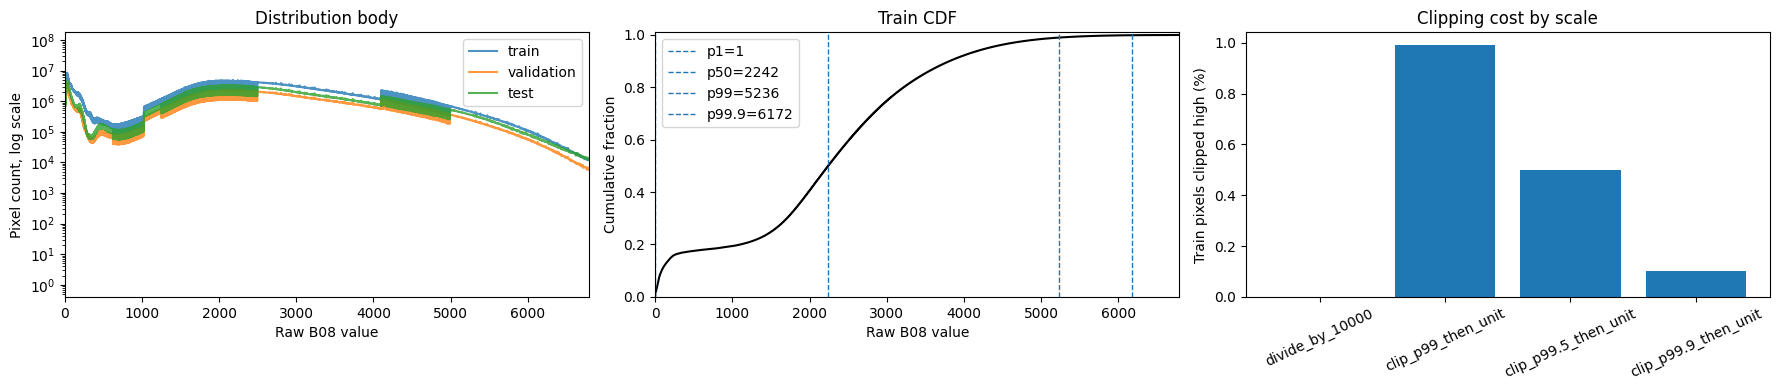

,normalization,upper_value,train_clipped_high_fraction,train_unit_mean_after_clip
0,divide_by_10000,10000,0.000002,0.218239
1,clip_p99_then_unit,5236,0.009914,0.415994
2,clip_p99.5_then_unit,5556,0.004990,0.392453
3,clip_p99.9_then_unit,6172,0.001000,0.353541


In [5]:
import matplotlib.pyplot as plt

train_percentiles = split_summaries[0]["percentiles"]
train_p1 = train_percentiles["1"]
train_p99 = train_percentiles["99"]
train_p995 = train_percentiles["99.5"]
train_p999 = train_percentiles["99.9"]
train_mean = split_summaries[0]["mean"]
train_std = split_summaries[0]["std"]

values = np.arange(65536)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for split, hist in split_histograms.items():
    populated = hist > 0
    axes[0].plot(values[populated], hist[populated], label=split, alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_xlim(0, max(train_p999 * 1.1, 1))
axes[0].set_xlabel("Raw B08 value")
axes[0].set_ylabel("Pixel count, log scale")
axes[0].set_title("Distribution body")
axes[0].legend()

train_cdf = np.cumsum(train_hist) / train_hist.sum()
axes[1].plot(values, train_cdf, color="black")
for percentile, value in [(1, train_p1), (50, train_percentiles["50"]), (99, train_p99), (99.9, train_p999)]:
    axes[1].axvline(value, linestyle="--", linewidth=1, label=f"p{percentile}={value}")
axes[1].set_xlim(0, max(train_p999 * 1.1, 1))
axes[1].set_ylim(0, 1.01)
axes[1].set_xlabel("Raw B08 value")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Train CDF")
axes[1].legend()

candidate_scales = {
    "divide_by_10000": 10000,
    "clip_p99_then_unit": train_p99,
    "clip_p99.5_then_unit": train_p995,
    "clip_p99.9_then_unit": train_p999,
}
clip_rows = []
for name, upper in candidate_scales.items():
    clip_rows.append(
        {
            "normalization": name,
            "upper_value": upper,
            "train_clipped_high_fraction": float(train_hist[upper + 1 :].sum() / train_hist.sum()),
            "train_unit_mean_after_clip": float((np.minimum(values, upper) * train_hist).sum() / train_hist.sum() / upper),
        }
    )
clip_df = pd.DataFrame(clip_rows)
axes[2].bar(clip_df["normalization"], clip_df["train_clipped_high_fraction"] * 100)
axes[2].set_ylabel("Train pixels clipped high (%)")
axes[2].set_title("Clipping cost by scale")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
display(clip_df)

In [6]:
normalization_recommendation = {
    "source_band": BAND,
    "source_dtype": "uint16",
    "train_mean_raw": train_mean,
    "train_std_raw": train_std,
    "train_p1_raw": train_p1,
    "train_p99_raw": train_p99,
    "sentinel2_reflectance_unit": {
        "formula": "x_unit = clip(x / 10000.0, 0.0, 1.0)",
        "to_diffusion_range": "x_model = 2.0 * x_unit - 1.0",
        "train_clipped_high_fraction": float(train_hist[10001:].sum() / train_hist.sum()),
    },
    "train_zscore": {
        "formula": "x_model = (x - train_mean_raw) / train_std_raw",
        "mean": train_mean,
        "std": train_std,
    },
    "robust_train_minmax": {
        "formula": "x_unit = clip((x - p1) / (p99 - p1), 0.0, 1.0)",
        "to_diffusion_range": "x_model = 2.0 * x_unit - 1.0",
        "p1": train_p1,
        "p99": train_p99,
    },
}

recommendation_path = STATS_ROOT / "b08_normalization_recommendation.json"
with recommendation_path.open("w", encoding="utf-8") as file:
    json.dump(normalization_recommendation, file, indent=2, sort_keys=True)
    file.write("\n")

print(f"Wrote {recommendation_path.relative_to(REPO_ROOT)}")
print("Training recommendation:")
print("- For image generation/diffusion losses, normalize B08 before training; raw uint16 values are not centered and have a long bright tail.")
print("- Start with Sentinel-2 reflectance scaling: clip(x / 10000, 0, 1), then map to [-1, 1] if the model expects image-like tensors.")
print("- Use the train-only mean/std constants for z-score models, or train p1/p99 for robust min-max experiments. Do not fit constants on validation/test.")
print(json.dumps(normalization_recommendation, indent=2))

Wrote data/derived/bigearthnet_s2_b08_5x5_stride3/stats/b08_normalization_recommendation.json
Training recommendation:
- For image generation/diffusion losses, normalize B08 before training; raw uint16 values are not centered and have a long bright tail.
- Start with Sentinel-2 reflectance scaling: clip(x / 10000, 0, 1), then map to [-1, 1] if the model expects image-like tensors.
- Use the train-only mean/std constants for z-score models, or train p1/p99 for robust min-max experiments. Do not fit constants on validation/test.
{
  "source_band": "B08",
  "source_dtype": "uint16",
  "train_mean_raw": 2182.399406496916,
  "train_std_raw": 1299.59817416683,
  "train_p1_raw": 1,
  "train_p99_raw": 5236,
  "sentinel2_reflectance_unit": {
    "formula": "x_unit = clip(x / 10000.0, 0.0, 1.0)",
    "to_diffusion_range": "x_model = 2.0 * x_unit - 1.0",
    "train_clipped_high_fraction": 2.2588567418938986e-06
  },
  "train_zscore": {
    "formula": "x_model = (x - train_mean_raw) / train_std_ra

In [7]:
# Standalone clipping-loss diagnostic for the already-created dataset.
# Information loss from Sentinel-2 scaling comes from clipping, not from dividing by 10000.0.
# Values in [0, 10000] remain order-preserving in float space; values >10000 all map to 1.0.
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm


def find_repo_root_for_clip_loss(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(f"Could not infer repository root from {start}")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root_for_clip_loss())
OUTPUT_ROOT = globals().get("OUTPUT_ROOT", REPO_ROOT / "data/derived/bigearthnet_s2_b08_5x5_stride3")
MANIFEST_ROOT = globals().get("MANIFEST_ROOT", OUTPUT_ROOT / "manifests")
STATS_ROOT = globals().get("STATS_ROOT", OUTPUT_ROOT / "stats")
SPLIT_ORDER = globals().get("SPLIT_ORDER", ["train", "validation", "test"])
S2_REFLECTANCE_SCALE = 10000
STATS_ROOT.mkdir(parents=True, exist_ok=True)


def load_manifest_rows(split: str) -> list[dict[str, Any]]:
    manifest_path = MANIFEST_ROOT / f"{split}.jsonl"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest: {manifest_path}")
    return [json.loads(line) for line in manifest_path.read_text().splitlines() if line.strip()]


def histogram_from_created_mosaics(rows: list[dict[str, Any]], split: str) -> np.ndarray:
    hist = np.zeros(65536, dtype=np.int64)
    missing_outputs = []

    for row in tqdm(rows, desc=f"Computing {split} B08 histogram"):
        image_path = REPO_ROOT / row["image_path"]
        if not image_path.exists():
            missing_outputs.append(str(image_path.relative_to(REPO_ROOT)))
            continue
        with rasterio.open(image_path) as src:
            array = src.read(1)
        hist += np.bincount(array.ravel(), minlength=65536)

    assert not missing_outputs, f"Missing {split} outputs, first examples: {missing_outputs[:5]}"
    return hist


def clipping_loss_summary(hist: np.ndarray, split: str, scale: int = S2_REFLECTANCE_SCALE) -> dict[str, float | int | str]:
    values = np.arange(hist.size, dtype=np.float64)
    weights = hist.astype(np.float64)
    total_pixels = int(hist.sum())
    if total_pixels == 0:
        raise ValueError(f"Cannot summarize empty histogram for {split}")

    clipped_mask = values > scale
    clipped_pixels = int(weights[clipped_mask].sum())
    raw_sum = float((values * weights).sum())
    clipped_values = np.minimum(values, scale)
    clipped_sum = float((clipped_values * weights).sum())
    lost_raw_units = raw_sum - clipped_sum

    raw_unit = values / scale
    clipped_unit = clipped_values / scale
    mse_unit = float((((raw_unit - clipped_unit) ** 2) * weights).sum() / total_pixels)
    mae_unit = float((np.abs(raw_unit - clipped_unit) * weights).sum() / total_pixels)
    nonzero_bins = np.flatnonzero(hist)

    return {
        "split": split,
        "scale": scale,
        "max_raw": int(nonzero_bins[-1]),
        "clipped_pixels": clipped_pixels,
        "clipped_pixel_fraction": clipped_pixels / total_pixels,
        "clipped_pixel_percent": 100 * clipped_pixels / total_pixels,
        "raw_signal_fraction_above_scale": float((values[clipped_mask] * weights[clipped_mask]).sum() / raw_sum),
        "raw_signal_fraction_lost_by_clipping": lost_raw_units / raw_sum,
        "mean_before_clip_unit": float(raw_sum / total_pixels / scale),
        "mean_after_clip_unit": float(clipped_sum / total_pixels / scale),
        "mean_shift_unit": float((clipped_sum - raw_sum) / total_pixels / scale),
        "mae_from_clip_unit": mae_unit,
        "rmse_from_clip_unit": math.sqrt(mse_unit),
        "distinct_raw_values_collapsed_to_one": int(np.count_nonzero(hist[scale + 1 :])),
    }


rows_by_split_for_clip_loss = {split: load_manifest_rows(split) for split in SPLIT_ORDER}
split_histograms_for_clip_loss = {
    split: histogram_from_created_mosaics(rows, split)
    for split, rows in rows_by_split_for_clip_loss.items()
}

clipping_loss_df = pd.DataFrame(
    [clipping_loss_summary(hist, split) for split, hist in split_histograms_for_clip_loss.items()]
).set_index("split")

display(
    clipping_loss_df[
        [
            "max_raw",
            "clipped_pixel_percent",
            "raw_signal_fraction_above_scale",
            "raw_signal_fraction_lost_by_clipping",
            "mean_before_clip_unit",
            "mean_after_clip_unit",
            "mean_shift_unit",
            "mae_from_clip_unit",
            "rmse_from_clip_unit",
            "distinct_raw_values_collapsed_to_one",
        ]
    ]
)

loss_path = STATS_ROOT / "b08_sentinel2_clip_loss.json"
with loss_path.open("w", encoding="utf-8") as file:
    json.dump(clipping_loss_df.reset_index().to_dict(orient="records"), file, indent=2, sort_keys=True)
    file.write("\n")

print(f"Wrote {loss_path.relative_to(REPO_ROOT)}")
print("Interpretation: clipped_pixel_percent is the share of pixels that lose exact raw magnitude; raw_signal_fraction_lost_by_clipping is the fraction of total raw B08 signal removed by capping values at 10000.")


Computing test B08 histogram: 100%|██████████| 8773/8773 [00:47<00:00, 183.54it/s]


,max_raw,clipped_pixel_percent,raw_signal_fraction_above_scale,raw_signal_fraction_lost_by_clipping,mean_before_clip_unit,mean_after_clip_unit,mean_shift_unit,mae_from_clip_unit,rmse_from_clip_unit,distinct_raw_values_collapsed_to_one
split,,,,,,,,,,
train,16672,0.000226,0.000013,0.000003,0.218240,0.218239,-6.425944e-07,6.425944e-07,0.000533,615
validation,16704,0.000263,0.000015,0.000003,0.228980,0.228979,-7.650747e-07,7.650747e-07,0.000588,580
test,16560,0.000123,0.000007,0.000002,0.228714,0.228714,-4.074927e-07,4.074927e-07,0.000435,503


Wrote data/derived/bigearthnet_s2_b08_5x5_stride3/stats/b08_sentinel2_clip_loss.json
Interpretation: clipped_pixel_percent is the share of pixels that lose exact raw magnitude; raw_signal_fraction_lost_by_clipping is the fraction of total raw B08 signal removed by capping values at 10000.


## Final Acceptance Checklist

After running all cells with `LIMIT_PER_SPLIT=None`:

- `manifests/train.jsonl` has 13,618 rows.
- `manifests/validation.jsonl` has 6,308 rows.
- `manifests/test.jsonl` has 8,773 rows.
- Every row has 25 source patch IDs and a sorted unique label union.
- Output GeoTIFFs are 600x600, single-band, uint16, compressed, and georeferenced.
- Preview PNGs exist under `previews/`.
- Train statistics exist at `stats/train_b08_stats.json`.
- Pixel diagnostics and normalization constants exist at `stats/b08_pixel_value_diagnostics.json`, `stats/b08_normalization_recommendation.json`, and `stats/b08_sentinel2_clip_loss.json`.